# Task 6 — Final comparative analysis of all methods.

In [3]:
# ── Imports ───────────────────────────────────────────────────────────
import sys
import importlib.util
import json
import numpy as np
import joblib
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "scripts"))

# ── Load regression adjustment ────────────────────────────────────────────────
ra_out        = np.load(ROOT / "data" / "regression_adjustment_outputs.npz")
theta_adj     = ra_out["theta_adj"]
theta_raw     = ra_out["theta_raw"]
ABC_QUANTILE  = float(ra_out["ABC_QUANTILE"])

# ── Load synthetic likelihood ─────────────────────────────────────────────────
sl_out         = np.load(ROOT / "data" / "synthetic_likelihood_outputs.npz")
posterior_sl   = sl_out["posterior_thin"]
acc_rate_sl    = float(sl_out["acc_rate"])

# ── Load MCMC chains ──────────────────────────────────────────────────────────
mcmc_out               = np.load(ROOT / "data" / "mcmc_chains.npz")
chain_balanced_best    = mcmc_out["chain_balanced_best"]
chain_lasso_best       = mcmc_out["chain_lasso_best"]
chain_semiauto_best    = mcmc_out["chain_semiauto_best"]

# ── Load SMC results ──────────────────────────────────────────────────────────
smc_out              = np.load(ROOT / "data" / "smc_results.npz")
smc_balanced_best    = smc_out["smc_balanced_best"]
smc_lasso_best       = smc_out["smc_lasso_best"]
smc_semiauto_best    = smc_out["smc_semiauto_best"]
eps_balanced_best    = smc_out["eps_balanced_best"]
eps_lasso_best       = smc_out["eps_lasso_best"]
eps_semiauto_best    = smc_out["eps_semiauto_best"]

# ── Load rejection ABC ────────────────────────────────────────────────────────
abc_out       = np.load(ROOT / "data" / "abc_rejection_outputs.npz")
epsilon       = float(abc_out["epsilon"])
feat_std      = abc_out["feat_std"]
distances     = abc_out["distances"]

data          = np.load(ROOT / "data" / "prior_simulations.npz")
thetas        = data["thetas"]

# ── Rejection ABC accepted draws ──────────────────────────────────────────────
accepted_mask  = distances <= epsilon
theta_rej_abc  = thetas[accepted_mask]

# ── Config ────────────────────────────────────────────────────────────────────
PRIOR_LOW  = np.array([0.05, 0.02, 0.0])
PRIOR_HIGH = np.array([0.50, 0.20, 0.8])
BURN_IN    = 1_000
labels     = ["β", "γ", "ρ"]
prior_std  = (PRIOR_HIGH - PRIOR_LOW) / np.sqrt(12)

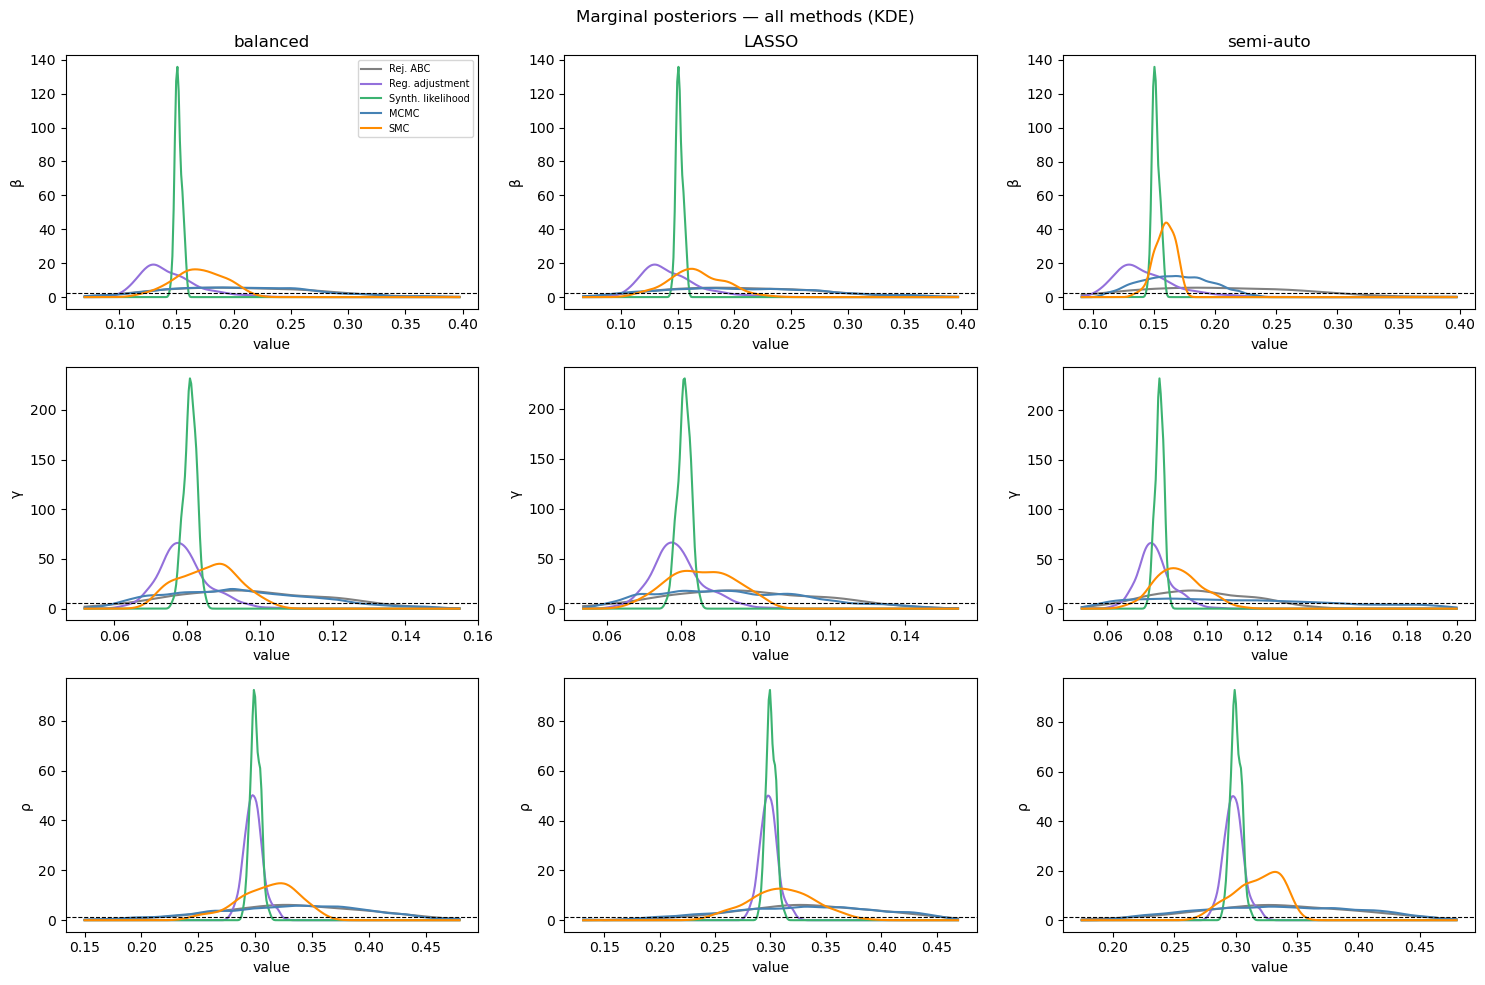

In [14]:
# ── Marginal posteriors — all methods ───────────────────────────────
from scipy.stats import gaussian_kde

burn_in = 1_000
fig, axes = plt.subplots(3, 3, figsize=(15, 10))

col_data = {
    "balanced":  (chain_balanced_best[burn_in:],  smc_balanced_best[-1]),
    "LASSO":     (chain_lasso_best[burn_in:],     smc_lasso_best[-1]),
    "semi-auto": (chain_semiauto_best[burn_in:],  smc_semiauto_best[-1]),
}

method_colors = {
    "Rej. ABC":          "grey",
    "Reg. adjustment":   "mediumpurple",
    "Synth. likelihood": "mediumseagreen",
    "MCMC":              "steelblue",
    "SMC":               "darkorange",
}

for col, (name, (mcmc_chain, smc_particles)) in enumerate(col_data.items()):
    for row, param in enumerate(labels):
        ax    = axes[row, col]
        xmin  = min(theta_rej_abc[:, row].min(), mcmc_chain[:, row].min(),
                    smc_particles[:, row].min(), posterior_sl[:, row].min(),
                    theta_adj[:, row].min())
        xmax  = max(theta_rej_abc[:, row].max(), mcmc_chain[:, row].max(),
                    smc_particles[:, row].max(), posterior_sl[:, row].max(),
                    theta_adj[:, row].max())
        x     = np.linspace(xmin, xmax, 300)

        for samples, label in [
            (theta_rej_abc,   "Rej. ABC"),
            (theta_adj,       "Reg. adjustment"),
            (posterior_sl,    "Synth. likelihood"),
            (mcmc_chain,      "MCMC"),
            (smc_particles,   "SMC"),
        ]:
            kde = gaussian_kde(samples[:, row])
            ax.plot(x, kde(x), lw=1.5, color=method_colors[label],
                    label=label if (row == 0 and col == 0) else None)

        ax.axhline(1 / (PRIOR_HIGH[row] - PRIOR_LOW[row]),
                   color="black", ls="--", lw=0.8)
        ax.set_ylabel(param)
        ax.set_xlabel("value")
        if row == 0:
            ax.set_title(name)

axes[0, 0].legend(fontsize=7, loc="upper right")
plt.suptitle("Marginal posteriors — all methods (KDE)")
plt.tight_layout()
plt.savefig(ROOT / "figures" / "comparison_all_methods_marginals.png", dpi=150, bbox_inches="tight")
plt.show()

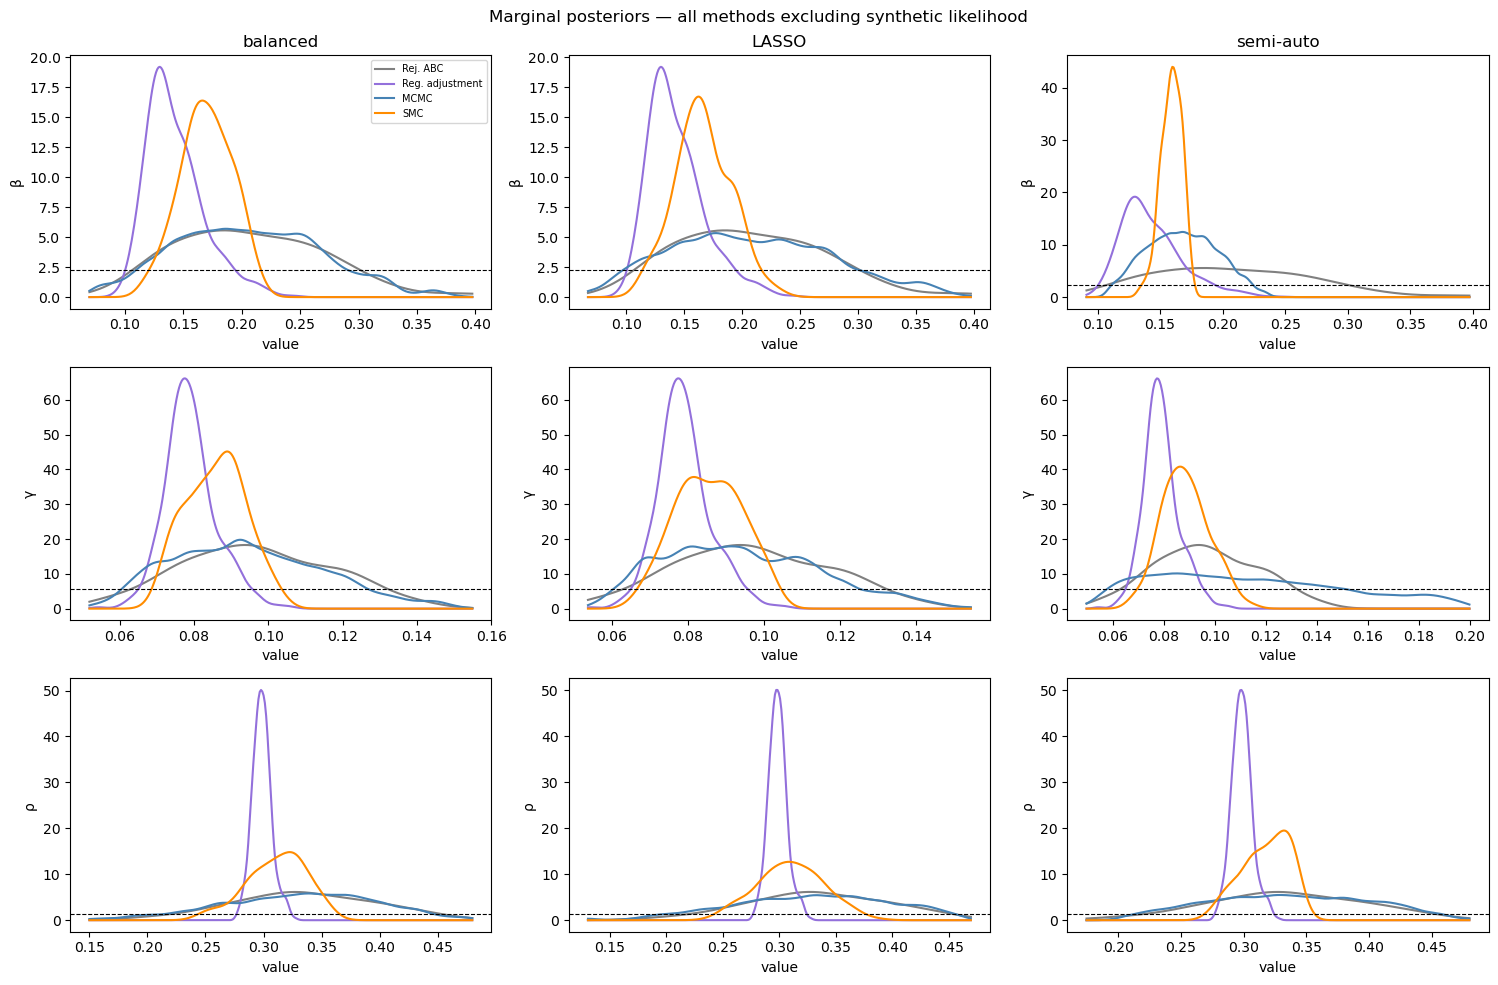

In [13]:
# ── Marginal posteriors — all methods (exclude synthetic likelihood) ───────────────────────────────
from scipy.stats import gaussian_kde

burn_in = 1_000
fig, axes = plt.subplots(3, 3, figsize=(15, 10))

col_data = {
    "balanced":  (chain_balanced_best[burn_in:],  smc_balanced_best[-1]),
    "LASSO":     (chain_lasso_best[burn_in:],     smc_lasso_best[-1]),
    "semi-auto": (chain_semiauto_best[burn_in:],  smc_semiauto_best[-1]),
}

method_colors = {
    "Rej. ABC":          "grey",
    "Reg. adjustment":   "mediumpurple",
    "MCMC":              "steelblue",
    "SMC":               "darkorange",
}

for col, (name, (mcmc_chain, smc_particles)) in enumerate(col_data.items()):
    for row, param in enumerate(labels):
        ax    = axes[row, col]
        xmin  = min(theta_rej_abc[:, row].min(), mcmc_chain[:, row].min(),
                    smc_particles[:, row].min(),
                    theta_adj[:, row].min())
        xmax  = max(theta_rej_abc[:, row].max(), mcmc_chain[:, row].max(),
                    smc_particles[:, row].max(),
                    theta_adj[:, row].max())
        x     = np.linspace(xmin, xmax, 300)

        for samples, label in [
            (theta_rej_abc,   "Rej. ABC"),
            (theta_adj,       "Reg. adjustment"),
            (mcmc_chain,      "MCMC"),
            (smc_particles,   "SMC"),
        ]:
            kde = gaussian_kde(samples[:, row])
            ax.plot(x, kde(x), lw=1.5, color=method_colors[label],
                    label=label if (row == 0 and col == 0) else None)

        ax.axhline(1 / (PRIOR_HIGH[row] - PRIOR_LOW[row]),
                   color="black", ls="--", lw=0.8)
        ax.set_ylabel(param)
        ax.set_xlabel("value")
        if row == 0:
            ax.set_title(name)

axes[0, 0].legend(fontsize=7, loc="upper right")
plt.suptitle("Marginal posteriors — all methods excluding synthetic likelihood")
plt.tight_layout()
plt.savefig(ROOT / "figures" / "comparison_all_methods_marginals_xsl.png", dpi=150, bbox_inches="tight")
plt.show()

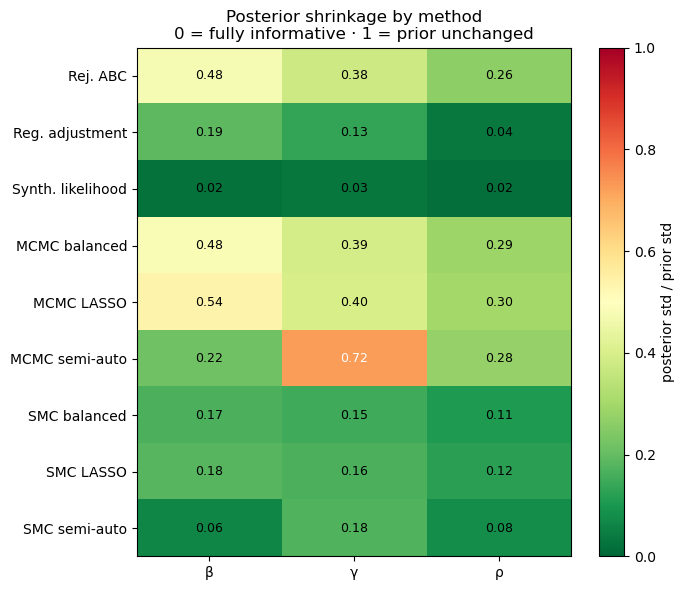

In [5]:
# ── Posterior shrinkage heatmap — all methods ──────────────────────
methods = {
    "Rej. ABC":         theta_rej_abc,
    "Reg. adjustment":  theta_adj,
    "Synth. likelihood":posterior_sl,
    "MCMC balanced":    chain_balanced_best[burn_in:],
    "MCMC LASSO":       chain_lasso_best[burn_in:],
    "MCMC semi-auto":   chain_semiauto_best[burn_in:],
    "SMC balanced":     smc_balanced_best[-1],
    "SMC LASSO":        smc_lasso_best[-1],
    "SMC semi-auto":    smc_semiauto_best[-1],
}

shrinkage = np.array([
    s.std(axis=0) / prior_std for s in methods.values()
])  # (n_methods, 3)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(shrinkage, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=1)
ax.set_xticks(range(3))
ax.set_xticklabels(labels)
ax.set_yticks(range(len(methods)))
ax.set_yticklabels(list(methods.keys()))
for i in range(len(methods)):
    for j in range(3):
        ax.text(j, i, f"{shrinkage[i, j]:.2f}",
                ha="center", va="center", fontsize=9,
                color="white" if shrinkage[i, j] > 0.6 else "black")
plt.colorbar(im, ax=ax, label="posterior std / prior std")
ax.set_title("Posterior shrinkage by method\n0 = fully informative · 1 = prior unchanged")
plt.tight_layout()
plt.savefig(ROOT / "figures" / "comparison_shrinkage_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

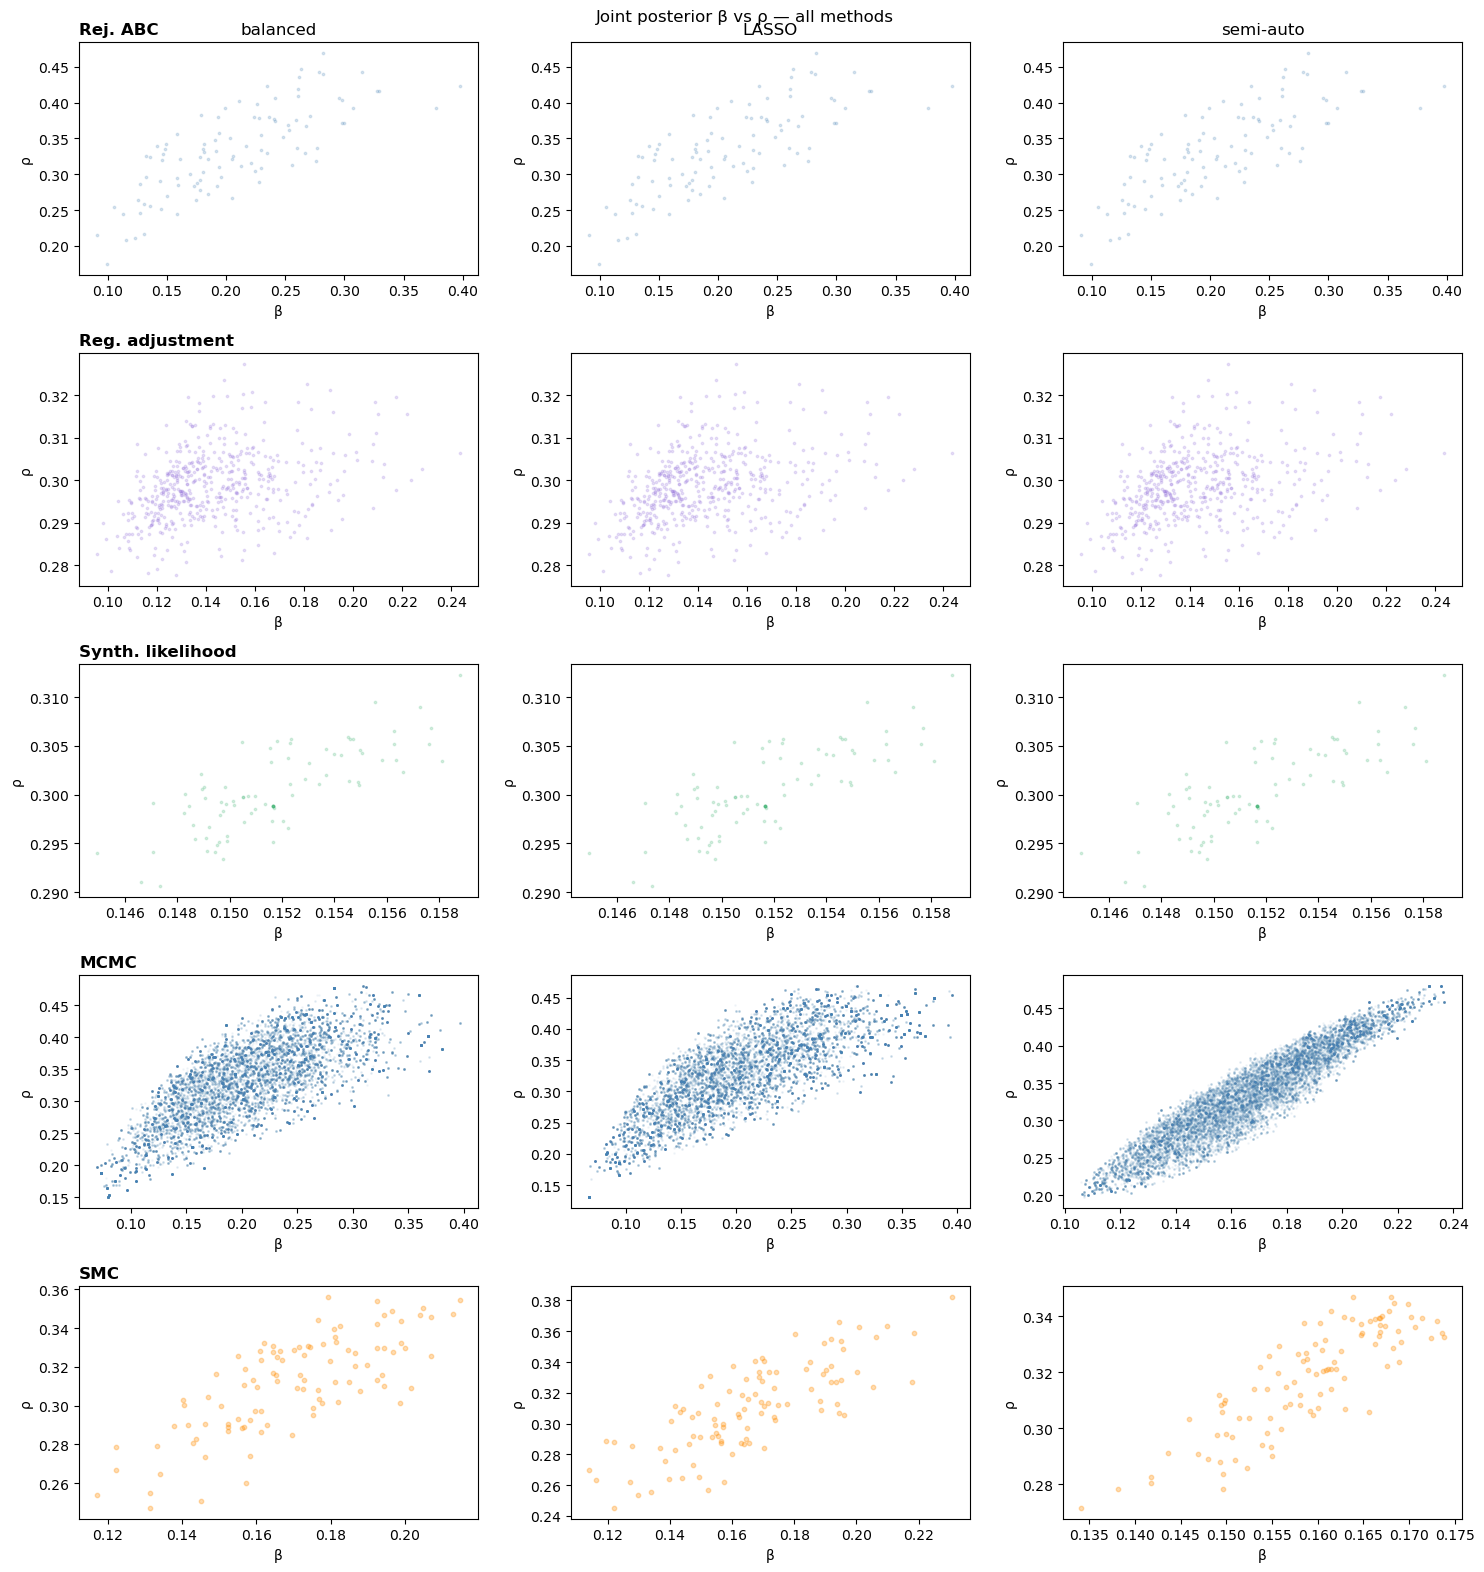

In [7]:
# ── Joint posterior β vs ρ — all methods ───────────────────────────
# Row 0: rejection ABC / reg adj / synth likelihood (same for all cols)
single_methods = [
    ("Rej. ABC",          theta_rej_abc,                  "steelblue"),
    ("Reg. adjustment",   theta_adj,                      "mediumpurple"),
    ("Synth. likelihood", posterior_sl,                   "mediumseagreen"),
]

fig, axes = plt.subplots(5, 3, figsize=(15, 16))

# Rows 0-2: single methods (same across all cols — just show once per row)
for row, (name, samples, color) in enumerate(single_methods):
    for col in range(3):
        ax = axes[row, col]
        ax.scatter(samples[:, 0], samples[:, 2],
                   alpha=0.2, s=3, color=color)
        ax.set_xlabel("β")
        ax.set_ylabel("ρ")
        if col == 0:
            ax.set_title(name, loc="left", fontweight="bold")
        if row == 0:
            ax.set_title(col_data[col][0])

# Row 3: MCMC per summary set
for col, (name, mcmc_chain, _) in enumerate(col_data):
    ax = axes[3, col]
    ax.scatter(mcmc_chain[:, 0], mcmc_chain[:, 2],
               alpha=0.05, s=1, color="steelblue")
    ax.set_xlabel("β")
    ax.set_ylabel("ρ")
    if col == 0:
        ax.set_title("MCMC", loc="left", fontweight="bold")

# Row 4: SMC per summary set
for col, (name, _, smc_particles) in enumerate(col_data):
    ax = axes[4, col]
    ax.scatter(smc_particles[:, 0], smc_particles[:, 2],
               alpha=0.3, s=10, color="darkorange")
    ax.set_xlabel("β")
    ax.set_ylabel("ρ")
    if col == 0:
        ax.set_title("SMC", loc="left", fontweight="bold")

plt.suptitle("Joint posterior β vs ρ — all methods")
plt.tight_layout()
plt.savefig(ROOT / "figures" / "comparison_joint_beta_rho.png", dpi=150, bbox_inches="tight")
plt.show()